## Introduction:

Decision trees are versatile machine learning algorithm capable of performing both regression and classification task and even work in case of tasks which has multiple outputs. They are powerful algorithms, capable of fitting even complex datasets. They are also the fundamental components of Random Forests, which is one of the most powerful machine learning algorithms available today.

By the end of the article, I assure you that you will know almost everything regarding decision trees. So let’s get started!
Table of content:

    -Training and visualizing a decision tree.
    -Journey to the predictions.
    -Samples, Values, and Gini?
    -Interpretations of the model.
    -Estimating class probability.
    -Complexity.
    -CART algorithm.
    -Regularize Hyperparameters.
    -Regression Using Decision trees.
    -Conclusion

Training and visualizing a decision tree:

To get a stronghold on this algorithm, let’s us build one and take a look at a journey our algorithm went through to make a particular prediction. In this article, we will be using the famous iris dataset for the explanation.

1. Importing iris dataset from sklearn.datasets and our decision tree classifier from sklearn.tree:

In [17]:
#1. Importing iris dataset from sklearn.datasets and our decision tree classifier from sklearn.tree:

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

#2. Initializing the X and Y parameters and loading our dataset:

iris = load_iris()
X = iris.data[:,2:]
y=iris.target

# Here, X is the feature attribute and y is the target attribute(ones we want to predict).

#3. Initializing a decision tree classifier with max_depth=2 and fitting our feature and target attributes in it.

tree_classifier = DecisionTreeClassifier(max_depth=2)
tree_classifier.fit(X,y)

DecisionTreeClassifier(max_depth=2)

All the hyperparameters in this model are set by default;

max_depth is the longest path between the root node and the leaf node(we will see at the time of example below).


Visualizing:

There are several ways of visualizing our trees:

1. Exporting decision trees to the text representation. It can be used while working on an application with UI(User Interface) or when we want to log information of model into a text file.

In [18]:
from sklearn.tree import export_text
txt_tree = export_text(tree_classifier)
print(txt_tree)

|--- feature_0 <= 2.45
|   |--- class: 0
|--- feature_0 >  2.45
|   |--- feature_1 <= 1.75
|   |   |--- class: 1
|   |--- feature_1 >  1.75
|   |   |--- class: 2



2. Using Plot_tree(requires matplotlib make sure to import it):

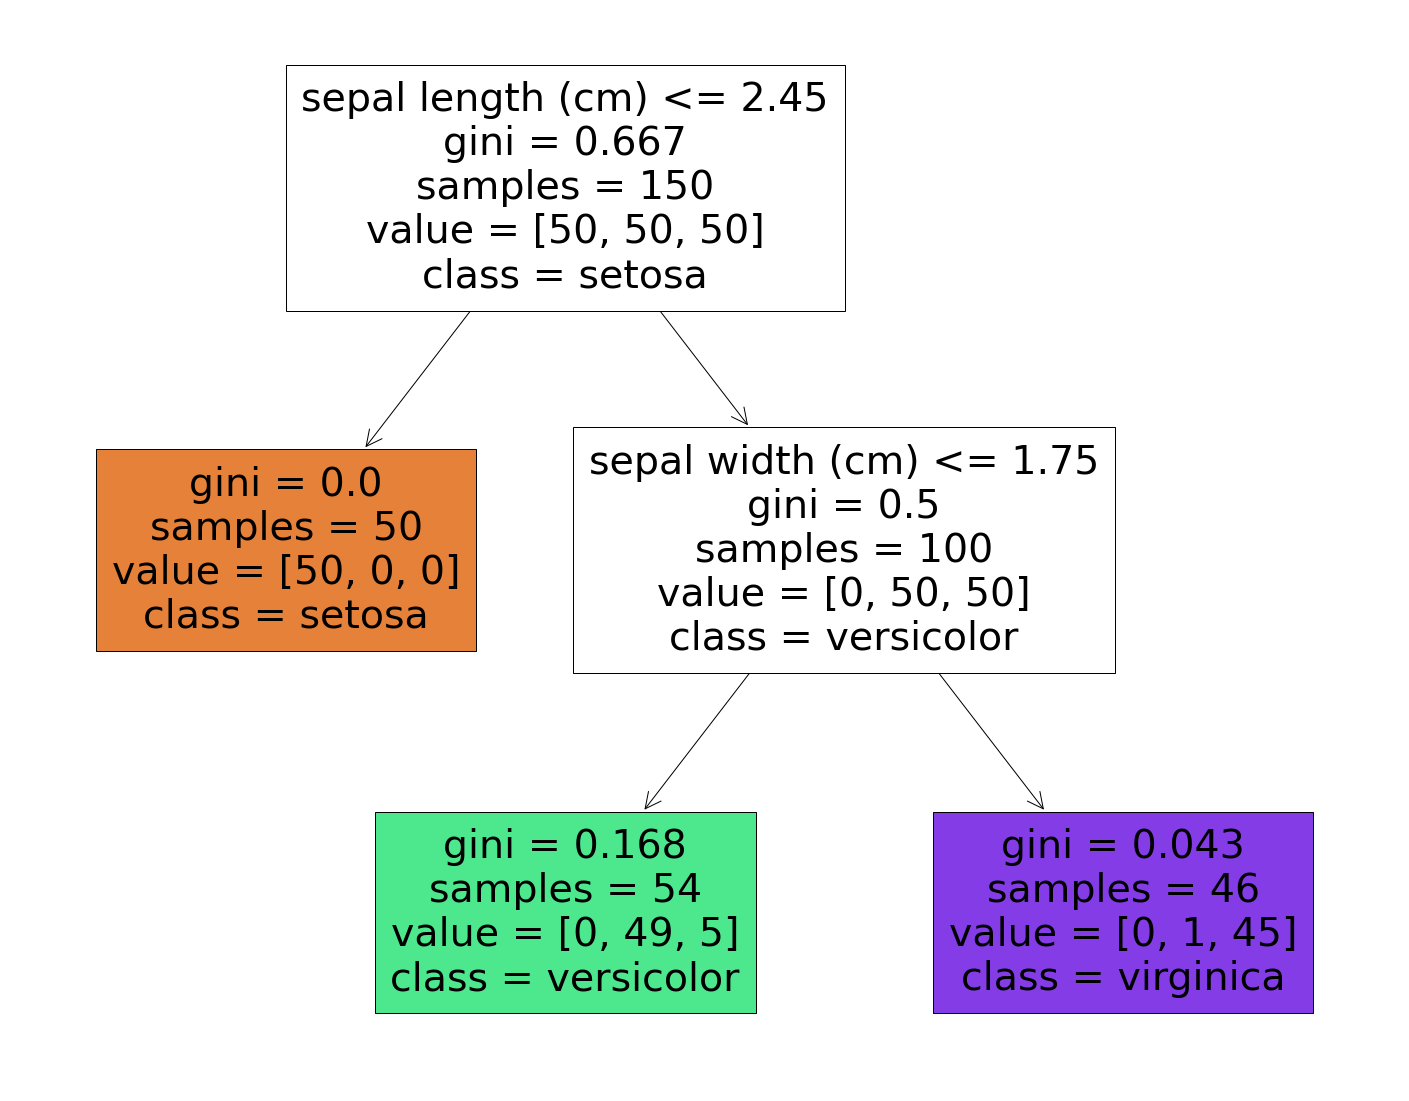

In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
%matplotlib inline
fig = plt.figure(figsize=(25,20))
_ = plot_tree(tree_classifier, 
                   feature_names=iris.feature_names,  
                   class_names=iris.target_names,
                   filled=True)

Veamos cómo el árbol de decisión anterior llega a las predicciones.

Supongamos que un día estás caminando en un jardín y encuentras una hermosa flor de iris y quieres clasificarla.

En primer lugar, comenzará desde el nodo raíz, que es la parte superior (profundidad 0): este nodo le pregunta si la longitud del pétalo de la flor es menor que 2,45 o no. Aquí suponemos que sí, luego bajamos al nodo secundario izquierdo de la raíz, que resulta ser un nodo hoja (uno sin nodos secundarios), por lo que no hace más preguntas: simplemente mira la clase de predicción para ese nodo y nuestro modelo predice que la flor que encontraste era Iris setosa.

Ahora suponga que encuentra otra flor, y esta vez la longitud del pétalo es mayor a 2,45 cm. Entonces, esta vez se mueve hacia el nodo secundario derecho de la raíz (profundidad 1), que no es un nodo de hoja, y hace otra pregunta si el ancho del pétalo es menor de 1,75 cm o no. En caso afirmativo, lo más probable es que su flor sea Iris versicolor. Si no, lo más probable es que su flor sea Iris virginica.

¡¡Simple!!

Entonces, una de las principales características o podemos decir ventajas de usar un árbol de decisión es que requieren menos preparación de datos. De hecho, no necesitan ningún tipo de escalado de funciones.

¿Muestras, valores y Gini?

Así que ahora debe preguntarse, ¿qué significan las muestras, los valores y el gini?

Muestras:

Aquí podemos decir que el atributo de muestras de un nodo cuenta a cuántas instancias de entrenamiento se aplica. Entendámoslo con la ayuda de un ejemplo, supongamos que 100 instancias de entrenamiento tienen una longitud de pétalo superior a 2,45 cm (profundidad 1 lado derecho), y de esas 100, 54 tienen un ancho de pétalo inferior a 1,75 cm (profundidad 2, lado izquierdo).

Valores:

Los atributos de valor le indican a cuántas instancias de entrenamiento de cada clase se aplica este nodo. Por ejemplo, si observamos la clase "Versicolor" en la parte inferior izquierda, tenemos 0 Iris setosa, 49 Iris Versicolor y 5 Iris Virginica.

Gini:

El atributo Gini de un nodo mide su impureza. Se dice que un nodo es puro cuando todas las instancias de entrenamiento que aplica pertenecen a la misma clase. Por ejemplo, podemos ver que en la clase Iris setosa gini parece ser 0, lo que significa que es "puro".

A continuación se proporciona una ecuación para calcular el puntaje de Gini:


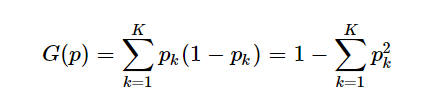

## Interpretación del modelo:

Como hemos visto aquí hoy, los árboles de decisión son realmente poderosos y sus decisiones son bastante fáciles de interpretar. Este tipo de modelos se conocen como modelos de caja blanca. En un futuro cercano, estaré subiendo blogs sobre redes neuronales que se consideran modelos de caja negra. De hecho, las redes neuronales ayudan a obtener excelentes predicciones y podemos verificar fácilmente los cálculos que realizan para dar una predicción. Pero es difícil explicar por qué se hicieron esas predicciones. Por ejemplo, supongamos que una red neuronal dice que Elon Musk parece estar en la imagen, es difícil saber qué llevó a esta predicción: ¿podrían haber sido ojos? o boca? o nariz? Es difícil interpretar eso. Pero definitivamente ese no es el caso con los árboles de decisión, ya que proporcionan reglas de clasificación simples que podemos aplicar manualmente si lo deseamos.

## Estimación de la probabilidad de clase:

También podemos estimar la probabilidad de que una instancia pertenezca a una clase en particular. Para calcular la probabilidad, lo que hace es recorrer para encontrar el nodo hoja para una instancia específica y luego devuelve la proporción de una instancia de la clase en este nodo. Por ejemplo, supongamos que encontramos una flor cuyo pétalo mide 4,5 cm de largo y 2 cm de ancho. Por lo tanto, el árbol de decisión debe generar las siguientes probabilidades: 0 % para Iris setosa, 2,1 % para Versicolor, 97,8 % para Iris virginica y, si desea predecir la clase, genera la clase 2 porque tiene la probabilidad más alta.

In [20]:
tree_classifier.predict_proba([[4.5,2]])

array([[0.        , 0.02173913, 0.97826087]])

In [21]:
tree_classifier.predict([[4.5,2]])

array([2])

## Complejidad:

Para hacer una predicción, necesitamos atravesar el árbol de decisión desde el nodo raíz hasta la hoja. Los árboles de decisión generalmente están equilibrados, por lo que, al atravesarlos, es necesario pasar aproximadamente por los nodos O (log2 (m)). Como sabemos que en cada nodo necesitamos verificar solo una característica, la complejidad de predicción general es O (log2 (m)), que es independiente de la cantidad de características. Por lo tanto, nuestras predicciones son extremadamente rápidas, incluso con grandes conjuntos de datos de entrenamiento.

Si comparamos todas las características con todas las muestras en cada nodo, la complejidad será de O(n x m log2(m)). Si sus conjuntos de datos de entrenamiento son pequeños, puede acelerar su entrenamiento preclasificando los datos (set presort = True), pero hacer esto en el caso de conjuntos de datos más grandes podría ralentizarlo.

## Algoritmo CART:

Sckit-Learn utiliza el algoritmo del árbol de clasificación y regresión (CART) para entrenar los árboles de decisión. Entonces, lo que hace este algoritmo es, en primer lugar, dividir el conjunto de entrenamiento en dos subconjuntos usando una sola función, digamos x y un umbral tx como en el ejemplo anterior, nuestro nodo raíz era "Longitud de pétalo" (x) y <= 2,45 cm (tx) . Ahora debe preguntarse cómo elige x y tx. Busca un par que produzca los subconjuntos más puros. Una vez que el algoritmo divide los conjuntos de entrenamiento en dos, divide los subconjuntos con el mismo método y así sucesivamente. Esto se detendrá cuando se alcance la profundidad máxima (el hiperparámetro que configuramos 2 anteriormente), o cuando no encuentre ninguna otra división que reduzca la impureza. Hay algunos otros hiperparámetros que controlan estas condiciones de parada, discutidos en la parte de regularización.

## Regularizaciones de Hiperparámetros:

Entonces, cuando se trata de árboles de decisión, la cuestión es que hace muy pocas suposiciones sobre los datos de entrenamiento (el modelo lineal asume que los datos que alimentará serán lineales). Si no lo limita, el árbol se adaptará a los datos de entrenamiento, lo que provocará un sobreajuste. Estos tipos de modelos a menudo se denominan modelos no paramétricos. Debido a que la cantidad de parámetros no se determina antes del entrenamiento, nuestro modelo es libre de ajustarse estrechamente a los datos de entrenamiento.

Para evitar este sobreajuste, debe restringir los árboles de decisión durante el entrenamiento. Las regularizaciones de los hiperparámetros dependen del algoritmo utilizado, pero al menos podría establecer la profundidad máxima del árbol de decisión. Esto se puede controlar mediante el hiperparámetro max_ depth que usamos anteriormente en el ejemplo, su valor predeterminado es Ninguno. La reducción del valor de max_ depth regularizará el modelo y, por lo tanto, evitará el riesgo de sobreajuste.

Los pocos otros hiperparámetros que restringirían la estructura del árbol de decisión son:

    min_samples_split: número mínimo de muestras que debe tener un nodo antes de dividirse.
    min_samples_leaf: número mínimo de muestras que debe poseer un nodo hoja.
    min_weight_fraction_leaf: fracción mínima de la suma total de los pesos necesarios para estar en un nodo de hoja.
    max_leaf_nodes: número máximo de nodos hoja que puede tener un árbol de decisión.
    max_features: número máximo de funciones que se tienen en cuenta para dividir cada nodo.

Recuerde que aumentar los hiperparámetros mínimos o reducir los hiperparámetros máximos regularizará el modelo.

## Regresión utilizando árboles de decisión:

Sí, los árboles de decisión también pueden realizar tareas de regresión. Avancemos y construyamos uno usando la clase DecisionTreeRegressor de Scikit-Learn, aquí estableceremos max_ depth = 5.

In [24]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
%matplotlib inline

In [25]:
dataset = np.array(
[[2,4],
 [3,9],
 [4,16],
 [5,25],
 [6,36],
 [8,64],
 [10,100],
 [12,144],
 [13,169]
])
X = dataset[:, 0:1].astype(int) 
y = dataset[:,1].astype(int)

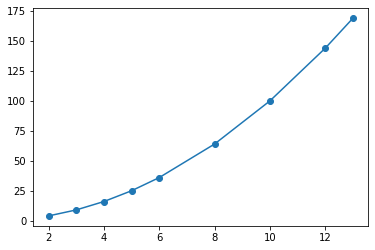

In [34]:
plt.plot(X,y,"-o")
plt.show()

Inicializando el modelo y ajustando los datos:

In [35]:
tree_regressor = DecisionTreeRegressor(max_depth=5)
tree_regressor.fit(X,y)

DecisionTreeRegressor(max_depth=5)

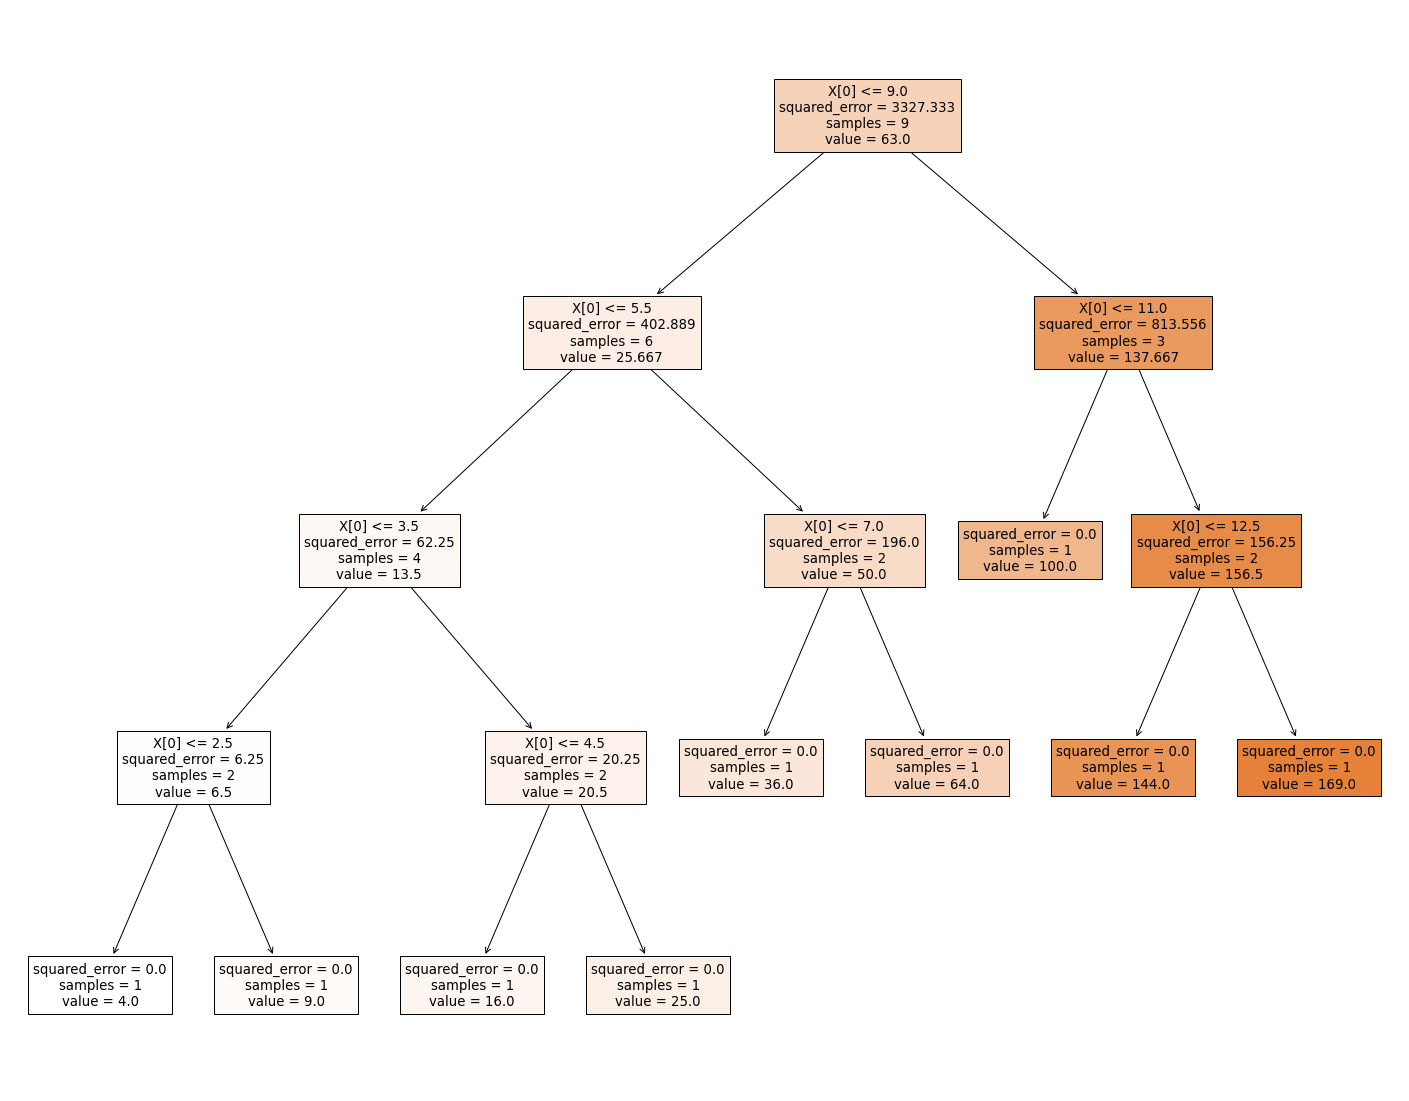

In [36]:
fig = plt.figure(figsize=(25,20))
_ = plot_tree(tree_regressor, 
                   filled=True)

Como podemos ver, este árbol se parece un poco al árbol que construimos antes. La diferencia es que en lugar de predecir la clase en cada nodo esta vez, predice un valor. Ya somos conscientes de atravesar el árbol, por lo que no lo haremos aquí.

El algoritmo Cart, aquí también funciona más o menos de la misma manera, excepto que aquí, en lugar de tratar de minimizar la impureza mientras se divide, se enfoca en minimizar el MSE (Error cuadrático medio).

Decision Tree mientras realiza las tareas de regresión también es propenso a sobreajustarse sin ninguna regularización, lo que definitivamente es el caso en nuestro ejemplo:

## Conclusión:

Muy bien, así que terminamos con una guía completa del árbol de decisión aquí. Por último, diría que los árboles de decisión son realmente fáciles de usar, comprender e interpretar. Pero el problema con los árboles de decisión es que son extremadamente sensibles a variaciones menores en los datos de entrenamiento. En realidad, si vuelve a entrenar su modelo en los mismos conjuntos de datos, puede obtener resultados diferentes porque el algoritmo de entrenamiento utilizado por Scikit-Learn es estocástico (selecciona aleatoriamente un conjunto de características), solo configure el hiperparámetro random_state para obtener los mismos resultados en el mismo entrenamiento conjuntos de datos El problema de la pequeña variación en el árbol de decisiones se puede contrarrestar mediante el uso de Random Forests,